In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

<h1>VQ-VAE vs VAE comparison</h1>

In [3]:
# Loading saved model loss data

# Training data
vae_training_loss = pd.read_csv("vae_average_train_loss.csv")
vqvae_training_loss = pd.read_csv("vqvae_average_train.csv")

# Validation data
vae_training_loss_val = pd.read_csv("vae_average_val_loss.csv")
vqvae_training_loss_val = pd.read_csv("vqvae_average_val.csv")

# Test data
vae_test_loss_val = pd.read_csv("vae_test_loss.csv")
vqvae_test_loss_val = pd.read_csv("vqvae_test_loss.csv")

In [4]:
result = {
    "VAE_TEST_BCE_LOSS" : vae_test_loss_val["average_bce_loss_test"].values[0].item(),
    "VQVAE_TEST_BCE_LOSS" : vqvae_test_loss_val["average_bce_loss_test"].values[0].item()
}
result

{'VAE_TEST_BCE_LOSS': 0.0627386598289013,
 'VQVAE_TEST_BCE_LOSS': 0.1627335205674171}

In [5]:
vae_training_loss.columns

Index(['bce_average_train_loss', 'mse_average_train_loss', 'epochs'], dtype='str')

In [6]:
vqvae_training_loss.columns

Index(['vq_average_loss', 'bce_average_train_loss', 'mse_average_train_loss',
       'epochs'],
      dtype='str')

VAE BCE loss average values over epochs


/tmp/ipykernel_4007230/1254861453.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


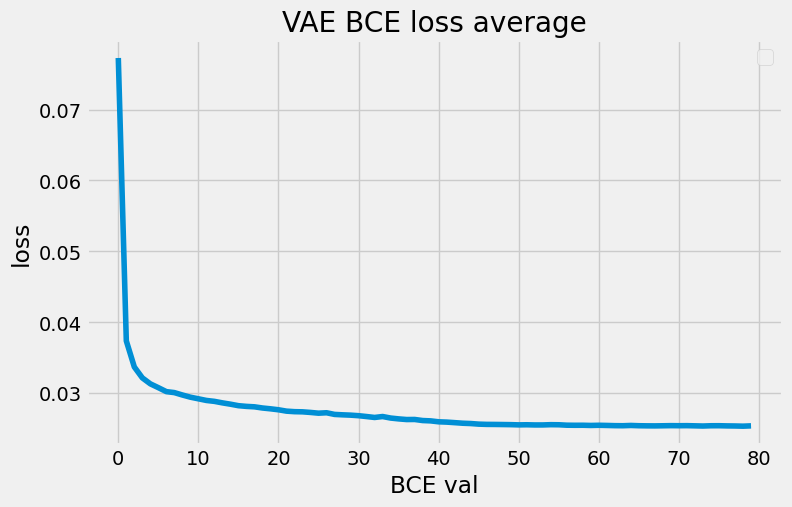

In [7]:
plot_metric_results(
    y_values=vae_training_loss["bce_average_train_loss"],
    x_values=vae_training_loss["epochs"],
    title="VAE BCE loss average",
    x_label="BCE val",
    y_title="loss"
)

VQ-VAE BCE + VQ loss average values over epochs


/tmp/ipykernel_4007230/1254861453.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


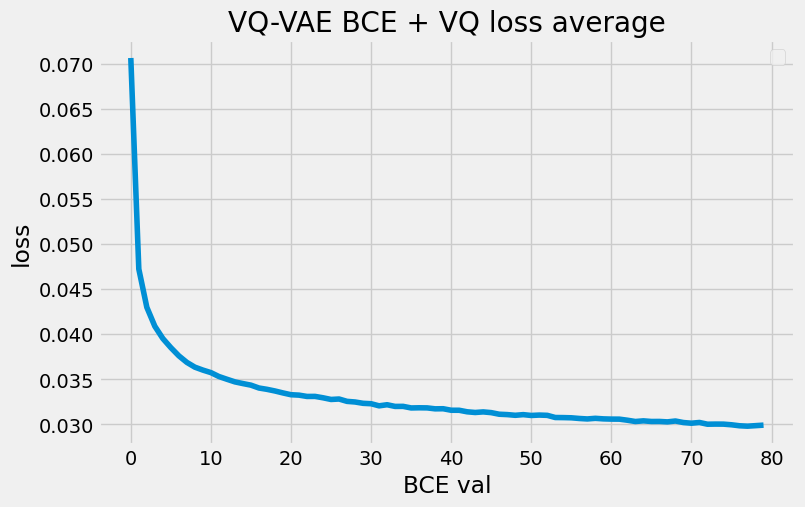

In [8]:
plot_metric_results(
    y_values=vqvae_training_loss["bce_average_train_loss"],
    x_values=vqvae_training_loss["epochs"],
    title="VQ-VAE BCE + VQ loss average",
    x_label="BCE val",
    y_title="loss"
)

Plotting curves training BCE and MSE training and validation loss curves


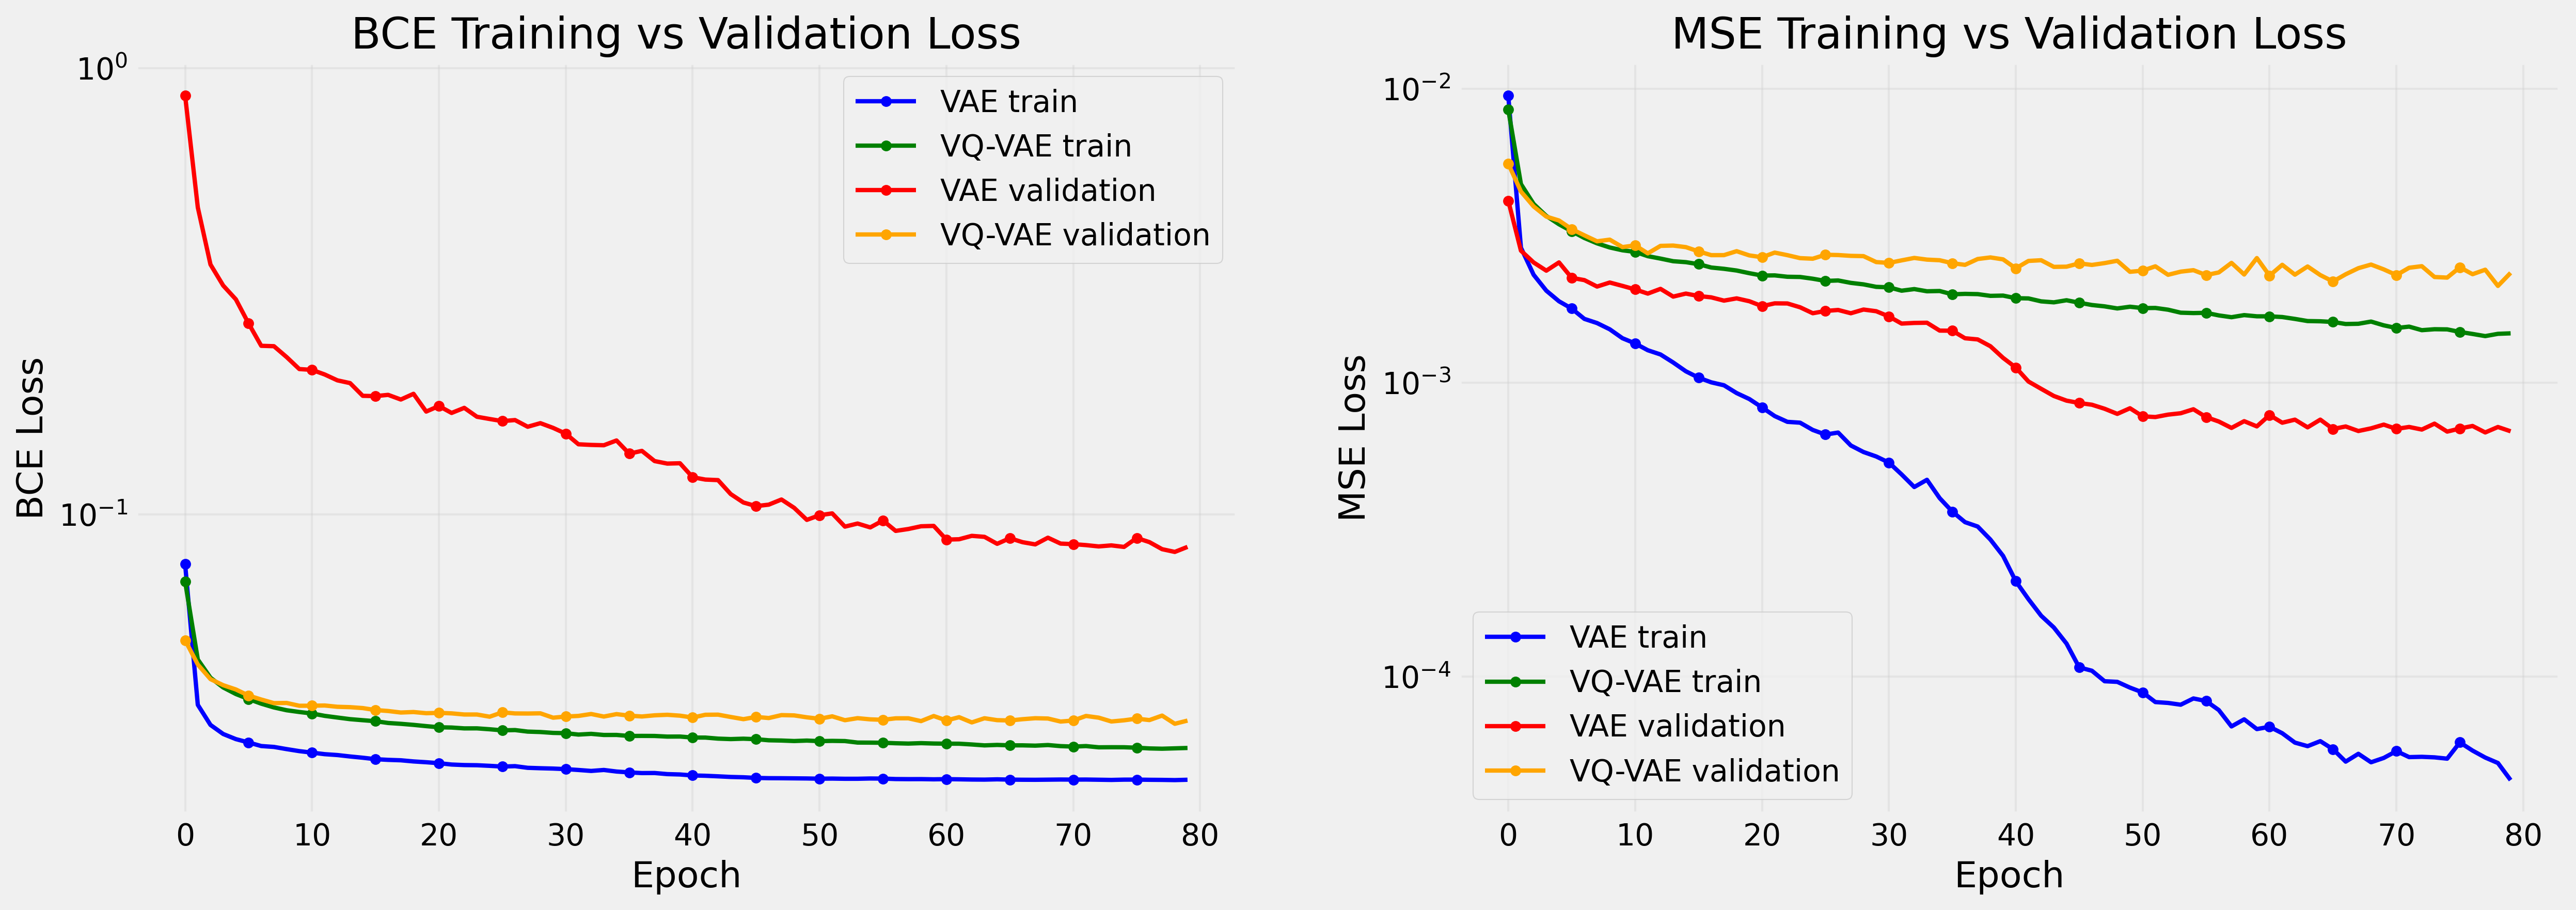

In [9]:
print("Plotting curves training BCE and MSE training and validation loss curves")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6),
    dpi=300
)

ax_bce = axes[0]
ax_mse = axes[1]
epochs = vae_training_loss["epochs"]
# colors = ["blue", "green", "red", "orange"]

model_bce_losses = [
    {
        "model" : "VAE",
        "type" : "bce",
        "loss" : vae_training_loss["bce_average_train_loss"],
        "color" : "blue",
        "data_type" : "train"
    },
    {
        "model" : "VQ-VAE",
        "type" : "bce",
        "loss" : vqvae_training_loss["bce_average_train_loss"],
        "color" : "green",
        "data_type" : "train"
    },
    {
        "model" : "VAE",
        "type" : "bce",
        "loss" : vae_training_loss_val["bce_average_val_loss"],
        "color" : "red",
        "data_type" : "validation"
    },
    {
        "model" : "VQ-VAE",
        "type" : "bce",
        "loss" : vqvae_training_loss_val["bce_average_val_loss"],
        "color" : "orange",
        "data_type" : "validation"
    }
]

model_losses_mse_train = [
    {
        "model" : "VAE",
        "type" : "mse",
        "loss" : vae_training_loss["mse_average_train_loss"],
        "color" : "blue",
        "data_type" : "train"
    },
    {
        "model" : "VQ-VAE",
        "type" : "mse",
        "loss" : vqvae_training_loss["mse_average_train_loss"],
        "color" : "green",
        "data_type" : "train"
    },
    {
        "model" : "VAE",
        "type" : "mse",
        "loss" : vae_training_loss_val["mse_average_val_loss"],
        "color" : "red",
        "data_type" : "validation"
    },
    {
        "model" : "VQ-VAE",
        "type" : "mse",
        "loss" : vqvae_training_loss_val["mse_average_val_loss"],
        "color" : "orange",
        "data_type" : "validation"
    }
]

# BCE train vs BCE validation
for (idx, curve) in enumerate(model_bce_losses):
    ax_bce.plot(
        epochs,
        curve["loss"],
        color=curve["color"],
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=4,
        markevery=5,
        label=f"{curve["model"]} {curve["data_type"]}"
    )
    
    ax_bce.set_title("BCE Training vs Validation Loss")
    ax_bce.set_xlabel("Epoch")
    ax_bce.set_ylabel("BCE Loss")
    ax_bce.legend()
    ax_bce.grid(True, alpha=0.3)
    ax_bce.set_yscale("log")

# plt.tight_layout()
# plt.show()

# MSE train vs MSE validation
for (idx, curve) in enumerate(model_losses_mse_train):
    ax_mse.plot(
        epochs,
        curve["loss"],
        color=curve["color"],
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=4,
        markevery=5,
        label=f"{curve["model"]} {curve["data_type"]}"
    )
    
    ax_mse.set_title("MSE Training vs Validation Loss")
    ax_mse.set_xlabel("Epoch")
    ax_mse.set_ylabel("MSE Loss")
    ax_mse.legend()
    ax_mse.grid(True, alpha=0.3)
    ax_mse.set_yscale("log")

In [10]:
# TODO: Validation plot VAE and BCE
# import numpy as np
# np.unique(vae_training_loss_val["mse_average_val_loss"])
